In [1]:
import pandas as pd
df = pd.read_csv('customer_shopping_behavior.csv')

In [2]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [4]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [5]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [6]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [7]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [8]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount_usd'})

In [9]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [10]:
labels = ['Youngster', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [11]:
df[['age', 'age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Youngster
2,50,Middle-aged
3,21,Youngster
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Youngster
8,26,Youngster
9,57,Middle-aged


In [12]:
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [13]:
df[['purchase_frequency_days', 'frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [14]:
df[['discount_applied','promo_code_used']].head()

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes


In [15]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [16]:
df = df.drop('promo_code_used', axis = 1)

In [17]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\welcome\AppData\Local\Temp\ipykernel_4780\2128627035.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_rev.values, y=category_rev.index, palette="viridis")


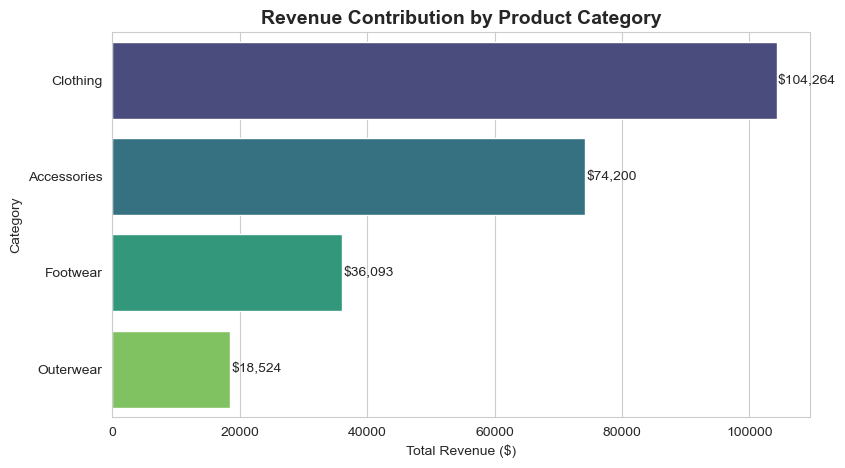

In [19]:
sns.set_style("whitegrid")

category_rev = df.groupby('category')['purchase_amount_usd'].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
ax = sns.barplot(x=category_rev.values, y=category_rev.index, palette="viridis")

plt.title("Revenue Contribution by Product Category", fontsize=14, fontweight='bold')
plt.xlabel("Total Revenue ($)")
plt.ylabel("Category")

for i, v in enumerate(category_rev.values):
    ax.text(v + 200, i, f"${v:,.0f}", va='center')

plt.show()

C:\Users\welcome\AppData\Local\Temp\ipykernel_4780\1896981926.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rev = df.groupby('age_group')['purchase_amount_usd'].sum().sort_values(ascending=False)
C:\Users\welcome\AppData\Local\Temp\ipykernel_4780\1896981926.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=age_rev.values, y=age_rev.index, palette="mako")


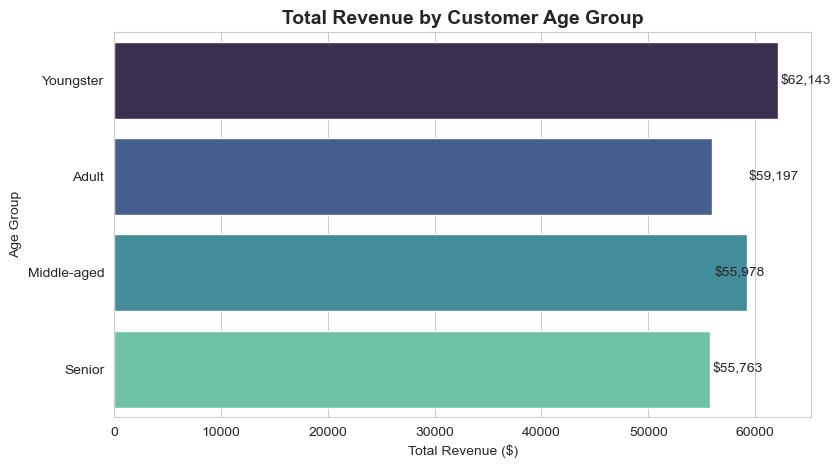

In [20]:
age_rev = df.groupby('age_group')['purchase_amount_usd'].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
ax = sns.barplot(x=age_rev.values, y=age_rev.index, palette="mako")

plt.title("Total Revenue by Customer Age Group", fontsize=14, fontweight='bold')
plt.xlabel("Total Revenue ($)")
plt.ylabel("Age Group")

for i, v in enumerate(age_rev.values):
    ax.text(v + 200, i, f"${v:,.0f}", va='center')

plt.show()

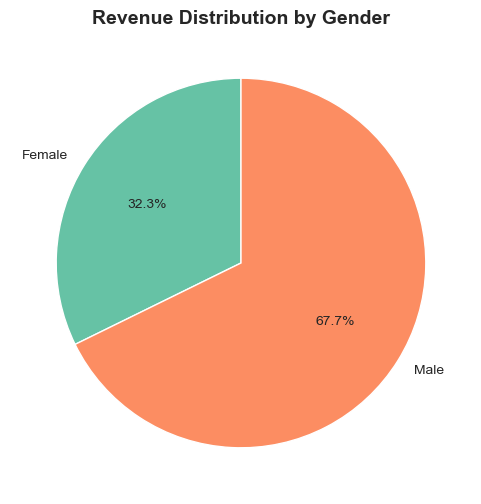

In [21]:
gender_rev = df.groupby('gender')['purchase_amount_usd'].sum()

plt.figure(figsize=(6,6))
plt.pie(gender_rev,
        labels=gender_rev.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette("Set2"))

plt.title("Revenue Distribution by Gender", fontsize=14, fontweight='bold')
plt.show()

In [22]:
# Create customer segments based on previous purchase behavior
df['customer_segment'] = pd.cut(
    df['previous_purchases'],
    bins=[-1, 10, 20, 30, df['previous_purchases'].max()],
    labels=['New', 'Growing', 'Established', 'Loyal']
)

df[['previous_purchases', 'customer_segment']].head()

,previous_purchases,customer_segment
0,14,Growing
1,2,New
2,23,Established
3,49,Loyal
4,31,Loyal


C:\Users\welcome\AppData\Local\Temp\ipykernel_4780\1095444164.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rev = df.groupby('age_group', as_index=False)['purchase_amount_usd'].sum() \
C:\Users\welcome\AppData\Local\Temp\ipykernel_4780\1095444164.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_rev = df.groupby('customer_segment', as_index=False)['purchase_amount_usd'].sum() \
C:\Users\welcome\AppData\Local\Temp\ipykernel_4780\1095444164.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0,

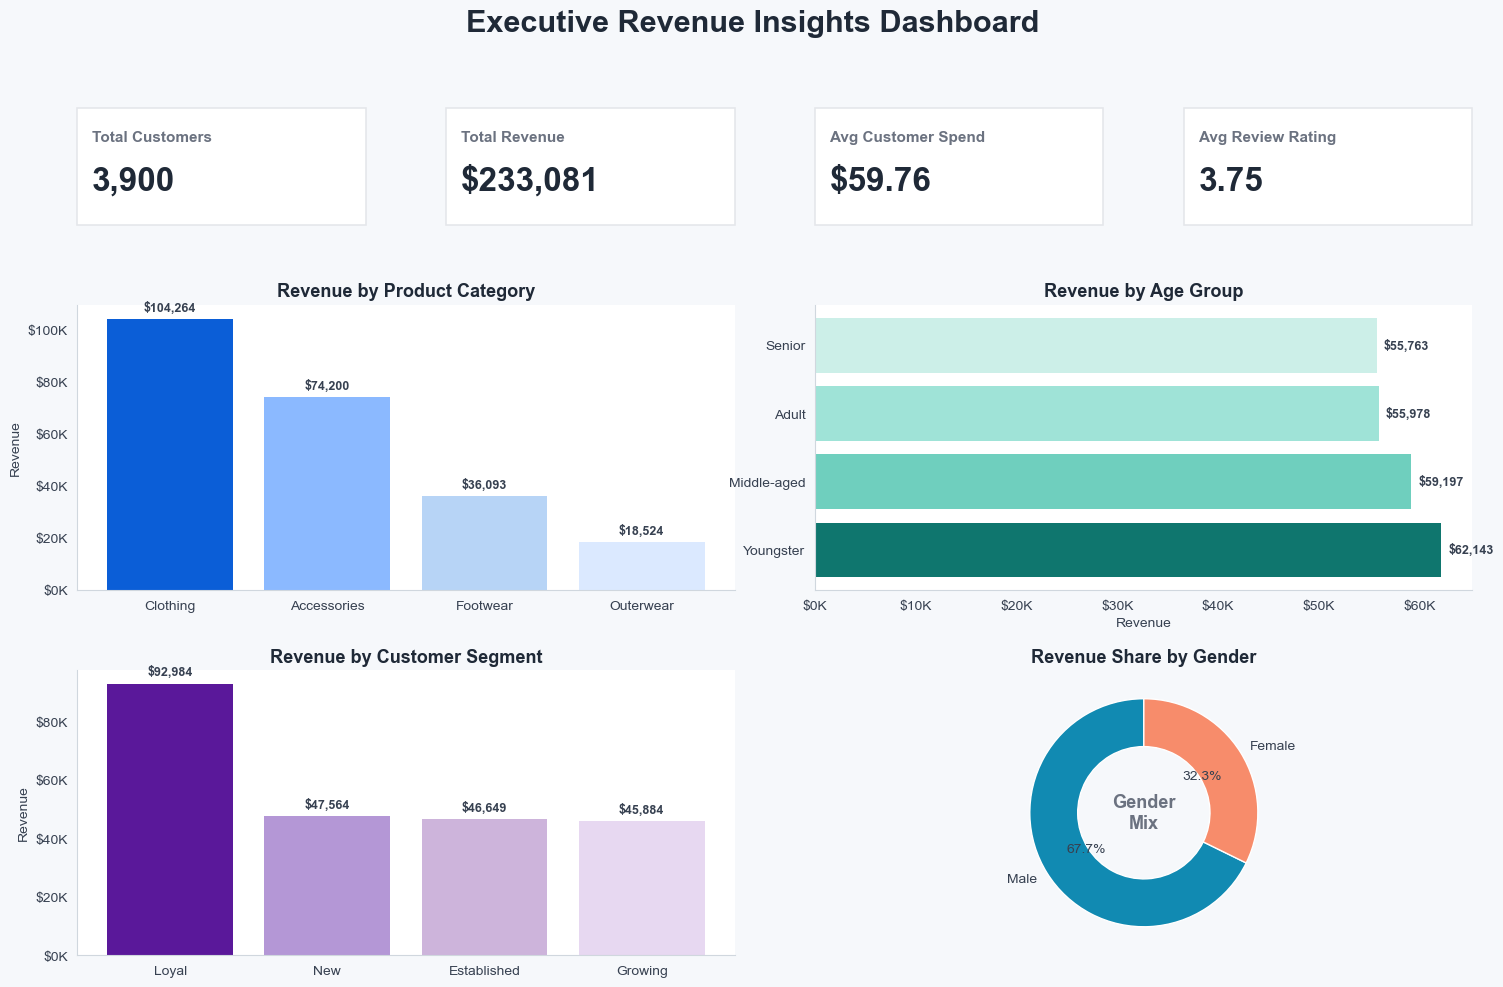

In [24]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# =========================
# Helper formatting
# =========================
def currency_k(x, pos):
    return f'${x/1000:.0f}K'

# =========================
# Aggregate data
# =========================
category_rev = df.groupby('category', as_index=False)['purchase_amount_usd'].sum() \
                 .sort_values('purchase_amount_usd', ascending=False)

age_rev = df.groupby('age_group', as_index=False)['purchase_amount_usd'].sum() \
            .sort_values('purchase_amount_usd', ascending=False)

segment_rev = df.groupby('customer_segment', as_index=False)['purchase_amount_usd'].sum() \
                .sort_values('purchase_amount_usd', ascending=False)

gender_rev = df.groupby('gender', as_index=False)['purchase_amount_usd'].sum() \
               .sort_values('purchase_amount_usd', ascending=False)

# =========================
# KPI values
# =========================
total_customers = df.shape[0]
total_revenue = df['purchase_amount_usd'].sum()
avg_spend = df['purchase_amount_usd'].mean()
avg_rating = df['review_rating'].mean()

# =========================
# Colors
# =========================
bg_color = '#f6f8fb'
card_bg = 'white'
title_color = '#1f2937'
text_color = '#374151'
muted_color = '#6b7280'
grid_color = '#d9dee7'

category_colors = ['#0b5ed7', '#8bb9ff', '#b7d4f6', '#dbe9ff']
age_colors = ['#0f766e', '#6fcfbe', '#9fe3d7', '#ccefe8']
segment_colors = ['#5a189a', '#b497d6', '#cdb4db', '#e7d8f1']
gender_colors = ['#118ab2', '#f78c6b']

# =========================
# Figure layout
# =========================
fig = plt.figure(figsize=(18, 11), facecolor=bg_color)
gs = fig.add_gridspec(3, 4, height_ratios=[0.9, 2.2, 2.2], hspace=0.35, wspace=0.28)

fig.suptitle(
    "Executive Revenue Insights Dashboard",
    fontsize=22,
    fontweight='bold',
    color=title_color,
    y=0.97
)

# =========================
# KPI cards
# =========================
kpi_titles = ["Total Customers", "Total Revenue", "Avg Customer Spend", "Avg Review Rating"]
kpi_values = [
    f"{total_customers:,.0f}",
    f"${total_revenue:,.0f}",
    f"${avg_spend:,.2f}",
    f"{avg_rating:.2f}"
]

for i in range(4):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(card_bg)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Border
    ax.patch.set_edgecolor('#e5e7eb')
    ax.patch.set_linewidth(1.2)

    ax.text(0.05, 0.72, kpi_titles[i], fontsize=11, color=muted_color, weight='bold')
    ax.text(0.05, 0.30, kpi_values[i], fontsize=24, color=title_color, weight='bold')

# =========================
# Common chart styling
# =========================
def style_axes(ax):
    ax.set_facecolor(card_bg)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#d0d7de')
    ax.spines['bottom'].set_color('#d0d7de')
    ax.tick_params(colors=text_color, labelsize=10)
    ax.title.set_color(title_color)
    ax.grid(alpha=0.18, linestyle='--', color=grid_color)
    ax.set_axisbelow(True)

# =========================
# Revenue by Category
# =========================
ax1 = fig.add_subplot(gs[1, 0:2])
style_axes(ax1)

bars = ax1.bar(
    category_rev['category'],
    category_rev['purchase_amount_usd'],
    color=category_colors,
    edgecolor='none'
)

ax1.set_title("Revenue by Product Category", fontsize=13, fontweight='bold')
ax1.set_ylabel("Revenue", fontsize=10, color=text_color)
ax1.yaxis.set_major_formatter(FuncFormatter(currency_k))
ax1.grid(axis='y')
ax1.grid(axis='x', visible=False)

for bar in bars:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h + 1800,
        f'${h:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=text_color
    )

# =========================
# Revenue by Age Group
# =========================
ax2 = fig.add_subplot(gs[1, 2:4])
style_axes(ax2)

bars = ax2.barh(
    age_rev['age_group'].astype(str),
    age_rev['purchase_amount_usd'],
    color=age_colors,
    edgecolor='none'
)

ax2.set_title("Revenue by Age Group", fontsize=13, fontweight='bold')
ax2.set_xlabel("Revenue", fontsize=10, color=text_color)
ax2.xaxis.set_major_formatter(FuncFormatter(currency_k))
ax2.grid(axis='x')
ax2.grid(axis='y', visible=False)

for bar in bars:
    w = bar.get_width()
    ax2.text(
        w + 700,
        bar.get_y() + bar.get_height() / 2,
        f'${w:,.0f}',
        va='center',
        fontsize=9,
        fontweight='bold',
        color=text_color
    )

# =========================
# Revenue by Customer Segment
# =========================
ax3 = fig.add_subplot(gs[2, 0:2])
style_axes(ax3)

bars = ax3.bar(
    segment_rev['customer_segment'].astype(str),
    segment_rev['purchase_amount_usd'],
    color=segment_colors,
    edgecolor='none'
)

ax3.set_title("Revenue by Customer Segment", fontsize=13, fontweight='bold')
ax3.set_ylabel("Revenue", fontsize=10, color=text_color)
ax3.yaxis.set_major_formatter(FuncFormatter(currency_k))
ax3.grid(axis='y')
ax3.grid(axis='x', visible=False)

for bar in bars:
    h = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        h + 1800,
        f'${h:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=text_color
    )

# =========================
# Revenue Share by Gender (Donut)
# =========================
ax4 = fig.add_subplot(gs[2, 2:4])
ax4.set_facecolor(card_bg)
for spine in ax4.spines.values():
    spine.set_visible(False)

wedges, texts, autotexts = ax4.pie(
    gender_rev['purchase_amount_usd'],
    labels=gender_rev['gender'],
    autopct='%1.1f%%',
    startangle=90,
    colors=gender_colors,
    wedgeprops=dict(width=0.42, edgecolor='white'),
    textprops=dict(color=text_color, fontsize=10)
)

ax4.set_title("Revenue Share by Gender", fontsize=13, fontweight='bold', color=title_color)
ax4.text(
    0, 0,
    "Gender\nMix",
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold',
    color=muted_color
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [18]:
pip install pymysql sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [20]:
!pip install psycopg2-binary sqlalchemy

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   -------------------------------------- - 2.6/2.7 MB 15.6 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 9.4 MB/s  0:00:00


In [22]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"      # default user
password = "admin123" # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "customer_behavior"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "customer"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'customer' in database 'customer_behavior'.
